## Load Pipeline Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/newworld/Downloads/311_master_dataset_validated.csv")
df['created_date'] = pd.to_datetime(df['created_date'])

## Grouping Logic

In [2]:
def map_complaint_group(ct):
    if pd.isna(ct):
        return 'Other'

    ct = str(ct).lower()

    housing_keywords = [
        'heat', 'hot water', 'plumbing', 'paint', 'plaster',
        'door', 'window', 'floor',
        'appliance', 'elevator', 'lead',
        'building', 'maintenance', 'facade', 'asbestos'
    ]

    transportation_keywords = [
        'parking', 'driveway', 'traffic', 'vehicle', 'obstruction'
    ]

    sanitation_keywords = [
        'sanitation', 'dirty', 'waste', 'dumping',
        'collection', 'rodent',
        'food', 'restaurant',
        'dead animal', 'residential disposal', 'graffiti'
    ]

    utilities_keywords = ['water', 'leak', 'electric', 'sewer']

    infrastructure_keywords = [
        'street', 'sidewalk', 'condition', 'light',
        'snow', 'ice'
    ]

    if 'noise' in ct:
        return 'Noise'
    elif any(x in ct for x in housing_keywords):
        return 'Housing'
    elif any(x in ct for x in transportation_keywords):
        return 'Transportation'
    elif any(x in ct for x in sanitation_keywords):
        return 'Sanitation'
    elif any(x in ct for x in utilities_keywords):
        return 'Utilities'
    elif any(x in ct for x in infrastructure_keywords):
        return 'Infrastructure'
    elif any(x in ct for x in ['encampment', 'homeless']):
        return 'Encampment / Social'
    elif 'tree' in ct:
        return 'Environment'
    else:
        return 'Other'
df['complaint_group'] = df['complaint_type'].apply(map_complaint_group)

## Monthly Trend Chart

This chart shows monthly trends in the top 5 complaint categories from 2024 to present, highlighting seasonal patterns and recent activity.

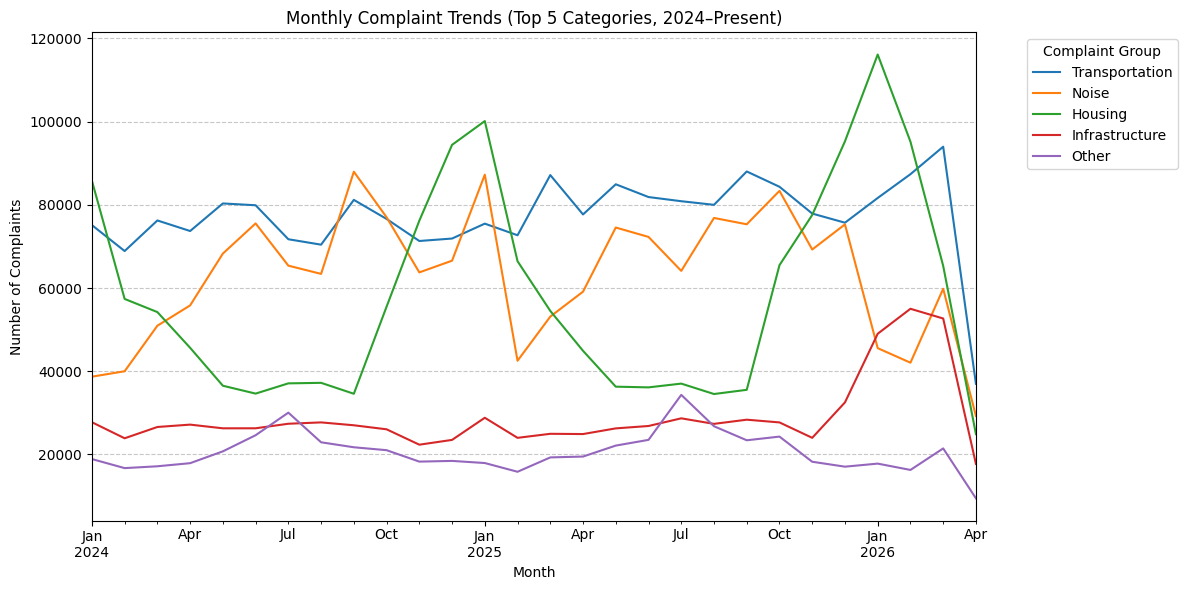

In [3]:
# Filter data (2024 → Present)
df_filtered = df[df['created_date'] >= '2024-01-01'].copy()

# Create month column
df_filtered['month'] = df_filtered['created_date'].dt.to_period('M')

# Group data
monthly = df_filtered.groupby(['month', 'complaint_group']).size().unstack()

# Select top 5 complaint groups (based on filtered data)
top_groups = df_filtered['complaint_group'].value_counts().head(5).index

# Sort months chronologically
monthly = monthly.sort_index()

# Plot
monthly[top_groups].plot(figsize=(12, 6))

plt.title("Monthly Complaint Trends (Top 5 Categories, 2024–Present)")
plt.ylabel("Number of Complaints")
plt.xlabel("Month")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Complaint Group", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

The final month (April 2026) is a partial period and shows lower counts due to incomplete data

## Year Over Year Growth Complaint Groups

This chart compares year-over-year growth between the two most recent complete years to identify which complaint categories are increasing or declining.

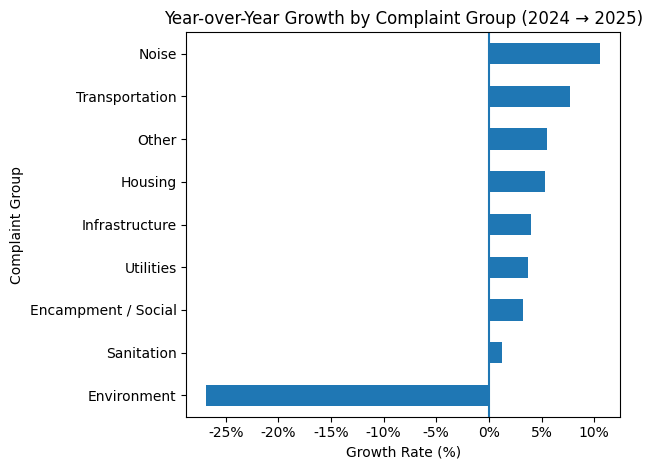

In [4]:
# Create year column (if not already created)
df['year'] = df['created_date'].dt.year

# Group data
yearly = df.groupby(['year', 'complaint_group']).size().unstack()

# Sort years to ensure order
yearly = yearly.sort_index()

# Select last two FULL years (exclude current partial year if needed)
years = yearly.index.tolist()

# Optional: remove most recent year if it's incomplete
latest_year = years[-1]
current_year = df['created_date'].max().year

if latest_year == current_year:
    yearly = yearly.iloc[:-1]

# Recalculate years after possible removal
years = yearly.index.tolist()

# Get last two valid years
y1, y2 = years[-2], years[-1]

# Calculate growth
growth = (yearly.loc[y2] - yearly.loc[y1]) / yearly.loc[y1]

# Plot
growth.sort_values().plot(kind='barh')

plt.axvline(0)
plt.title(f"Year-over-Year Growth by Complaint Group ({y1} → {y2})")
plt.xlabel("Growth Rate (%)")
plt.ylabel("Complaint Group")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)

plt.tight_layout()
plt.show()

Year-over-year comparison remains unchanged, as 2026 represents a partial year and is excluded from the analysis.